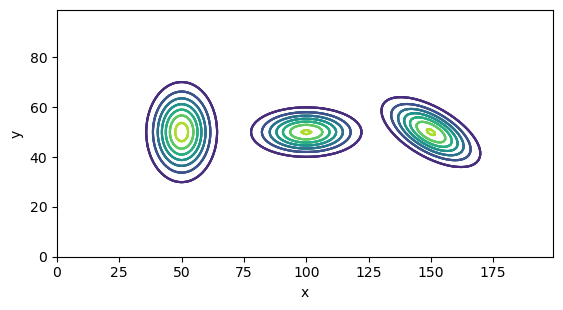

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import multivariate_normal 
import math

x,y = np.mgrid[0:200,0:100]   
pos = np.empty(x.shape+(2,))   
pos[:,:,0] = x           
pos[:,:,1] = y 

a = multivariate_normal(mean=[50,50],cov=[[50,0],[0,100]])
b = multivariate_normal(mean=[100,50],cov=[[125,0],[0,25]])
c = multivariate_normal(mean=[150,50],cov=[[100,-25*math.sqrt(3)],[-25*math.sqrt(3),50]])
for e in [a,b,c]:
    plt.contour(x,y,e.pdf(pos))
    
plt.gca().set_aspect('equal') #gca: 図を管理しているAxisというオブジェクトを返す
plt.gca().set_xlabel('x')
plt.gca().set_ylabel('y')
plt.show()

In [9]:
eig_vals,eig_vec=np.linalg.eig(c.cov)    #linalg.eigは固有ベクトルの長さを1で返す
print(f"""
eig_vals:{eig_vals}
eig_vec: {eig_vec}
固有値ベクトル1:{eig_vec[:,0]}      
固有値ベクトル2:{eig_vec[:,1]}
""")
#eig_vecの縦の列が固有値ベクトルに対応


eig_vals:[125.  25.]
eig_vec: [[ 0.8660254  0.5      ]
 [-0.5        0.8660254]]
固有値ベクトル1:[ 0.8660254 -0.5      ]      
固有値ベクトル2:[0.5       0.8660254]



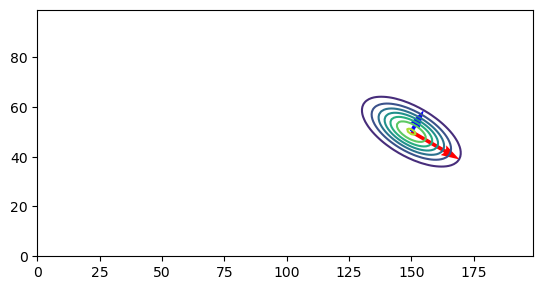

In [10]:
plt.contour(x,y,c.pdf(pos))

v = 2*math.sqrt(eig_vals[0])*eig_vec[:,0]
plt.quiver(c.mean[0],c.mean[1],v[0],v[1],color="red",angles='xy',scale_units='xy',scale=1)
#quiverは矢印を描くためのメソッド　引数は始点のx,y座標、ベクトルのx,y座標の長さ、色、図の縮尺通りに出力するためのパラメータ
v = 2*math.sqrt(eig_vals[1])*eig_vec[:,1]
plt.quiver(c.mean[0],c.mean[1],v[0],v[1],color="blue",angles='xy',scale_units='xy',scale=1)

plt.gca().set_aspect('equal')
plt.show()

In [ ]:
V=eig_vec
L=np.diag(eig_vals) #np.diagで対角行列を作成

print("分解したものを計算：\n",V.dot(L.dot(np.linalg.inv(V))))
print("元の共分散行列：\n",np.array())